# Phase 6 — Interactive PM Evidence Card

## 1. PM question

**Is the current momentum environment becoming fragile, what is driving the
change, and what evidence would confirm or invalidate the warning?**

This system *monitors fragility conditions*. It does **not** claim perfect
momentum-crash prediction. Momentum crashes are rare and state-dependent, so
the deterministic rules describe conditions under which a rebound could
squeeze the recent-loser leg — not a forecast that a crash will occur.

## 2. Architecture

```
Structured market data
        |
Deterministic risk indicators   (Phase 1 regime, Phase 3 leg risk)
        |
Risk-state and trigger engine   (Phase 4 four-row scorecard)
        |
Point-in-time evidence retrieval (cached, cutoff-enforced)
        |
Optional structured LLM synthesis (narrative text only; numbers untouched)
        |
PM Evidence Card
```

Every number on the card comes from the frozen Phase 1–4 code paths. The
optional synthesis layer only phrases narrative text and can never write a
quantitative field.

In [1]:
# Bootstrap: make `import src` work whether the kernel starts in the repo
# root or in notebooks/.
import sys, pathlib
_root = pathlib.Path.cwd()
if not (_root / 'src').exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, display
from src.mvp.evidence_card import (
    build_evidence_card,
    render_evidence_card_html,
    render_signal_table_html,
)

In [2]:
# ============================================================
# DEMO CONFIGURATION — EDIT THESE, THEN RUN ALL
# ============================================================
DEMO_MODE = True
AS_OF_DATE = "2024-01-05"        # quant history + cached point-in-time evidence
COMPARE_TO_DATE = "2023-12-01"   # set to None to skip change analysis
THRESHOLD_PROFILE = "default"    # only the approved default is supported
USE_LLM = False                   # reliable default; True still fails safely without a configured synthesizer

# Other dates to try:
#   AS_OF_DATE, COMPARE_TO_DATE = "2020-03-24", "2020-02-24"  # elevated quant case
#   AS_OF_DATE, COMPARE_TO_DATE = "2026-05-29", "2026-04-30"  # recent normal case

In [3]:
card = build_evidence_card(
    as_of_date=pd.Timestamp(AS_OF_DATE),
    compare_to_date=pd.Timestamp(COMPARE_TO_DATE) if COMPARE_TO_DATE else None,
    threshold_profile=THRESHOLD_PROFILE,
    use_llm=USE_LLM,
)
print(f"Ready — {card.as_of_date} | state={card.overall_risk_state} | "
      f"evidence={card.evidence_quality} | synthesis={card.synthesis_mode} | run={card.run_id}")

Ready — 2024-01-05 | state=bear_low_volatility | evidence=available | synthesis=deterministic_no_llm | run=53c34aa57bb437fc


## 3. Inputs and run metadata

In [4]:
tail = 'unavailable' if card.tail_loss_frequency is None else f'{card.tail_loss_frequency:.2%}'
Markdown(
    '| Field | Value |\n|---|---|\n'
    f'| Selected date | `{card.as_of_date}` |\n'
    f'| Comparison date | `{card.comparison_date}` |\n'
    f'| Threshold profile | `{card.threshold_profile}` |\n'
    f'| Data cutoff | `{card.data_cutoff}` |\n'
    f'| LLM requested / result | `{card.llm_enabled}` / `{card.synthesis_mode}` |\n'
    f'| {card.tail_loss_horizon_days}-day conditional tail-loss freq (descriptive) | {tail} |\n'
    f'| Data version | `{card.data_version}` |\n'
    f'| Quant model version | `{card.quant_model_version}` |\n'
    f'| Run ID | `{card.run_id}` |\n'
)

| Field | Value |
|---|---|
| Selected date | `2024-01-05` |
| Comparison date | `2023-12-01` |
| Threshold profile | `default` |
| Data cutoff | `2024-01-05T16:00:00-05:00` |
| LLM requested / result | `False` / `deterministic_no_llm` |
| 20-day conditional tail-loss freq (descriptive) | 8.17% |
| Data version | `sha256:3ed1ffe1a49a778d` |
| Quant model version | `phase-1-4-deterministic-v1:0c8b489894c8` |
| Run ID | `53c34aa57bb437fc` |


### Date-interactivity regression check

This lightweight check computes two fixed historical dates through the same
entry point and fails loudly if the quantitative card is accidentally fixed.

In [5]:
_check_a = build_evidence_card(
    as_of_date=pd.Timestamp('2024-01-05'),
    compare_to_date=pd.Timestamp('2023-12-01'),
    use_llm=False,
)
_check_b = build_evidence_card(
    as_of_date=pd.Timestamp('2020-03-24'),
    compare_to_date=pd.Timestamp('2020-02-24'),
    use_llm=False,
)
_signature = lambda c: (
    c.overall_risk_state,
    tuple((s.name, s.current_value, s.status) for s in c.triggered_quant_signals + c.non_triggered_relevant_signals),
)
assert _signature(_check_a) != _signature(_check_b)
assert _check_a.run_id != _check_b.run_id
assert _check_a.evidence_quality != _check_b.evidence_quality
print(
    f'PASS — 2024-01-05: {_check_a.overall_risk_state}, '
    f'{len(_check_a.triggered_quant_signals)} triggers, evidence {_check_a.evidence_quality}; '
    f'2020-03-24: {_check_b.overall_risk_state}, '
    f'{len(_check_b.triggered_quant_signals)} triggers, evidence {_check_b.evidence_quality}'
)

PASS — 2024-01-05: bear_low_volatility, 0 triggers, evidence available; 2020-03-24: panic_elevated, 3 triggers, evidence unavailable


## 4. Quantitative state

The risk state and four Phase 4 indicators are computed by the deterministic
pipeline. The narrative and evidence layers cannot change them.

In [6]:
display(HTML(
    f"<div style='padding:10px 14px;border-left:5px solid #555'>"
    f"<strong>{card.overall_risk_state.replace('_', ' ').title()}</strong> — "
    f"{len(card.triggered_quant_signals)} of "
    f"{len(card.triggered_quant_signals + card.non_triggered_relevant_signals)} indicators triggered.<br>"
    f"<span>{card.narrative_state}</span></div>"
))
display(HTML(render_signal_table_html(card)))

Indicator,Current,Trigger rule,Status,Δ vs compare
High Volatility Recovery,0.0000,≥ 1.0000,not_triggered,+0.0000
Short Minus Long Beta Gap,-0.5179,≥ 0.7116,not_triggered,-0.2747
Portfolio Drawdown,-0.0903,≤ -0.2000,not_triggered,+0.0098
Short Loss In Recovery,0.2039,≥ 0.2905,not_triggered,-0.0599


### Selected-date time-series context

The trailing year is clipped at the selected date. Threshold lines are the
prior-only rules computed for that selected date.

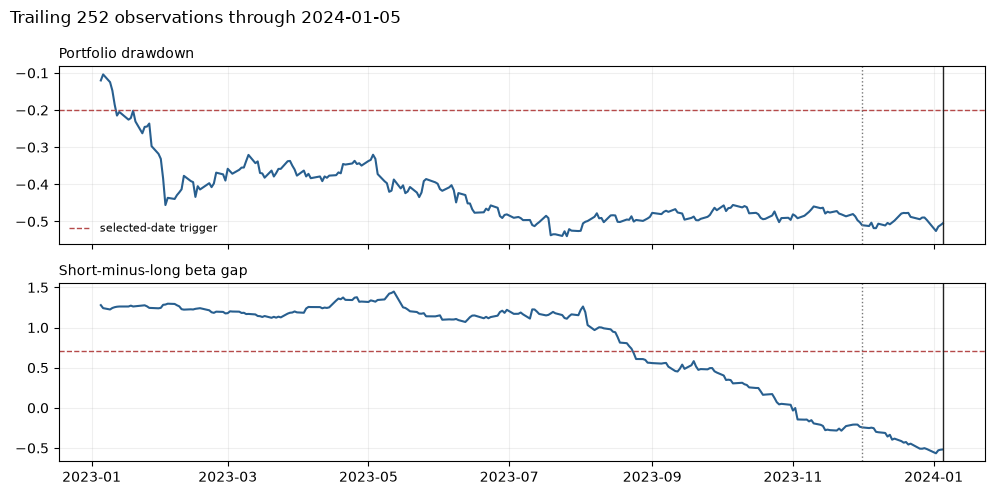

In [7]:
risk_history = pd.read_parquet(
    _root / 'data/processed/leg_risk_history.parquet',
    columns=['date', 'portfolio_drawdown', 'beta_gap_short_minus_long_126d'],
)
risk_history['date'] = pd.to_datetime(risk_history['date'])
risk_history = risk_history.loc[risk_history['date'].le(pd.Timestamp(AS_OF_DATE))].tail(252)
signal_by_name = {
    signal.name: signal
    for signal in card.triggered_quant_signals + card.non_triggered_relevant_signals
}
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
series = [
    ('portfolio_drawdown', 'portfolio_drawdown', 'Portfolio drawdown'),
    ('beta_gap_short_minus_long_126d', 'short_minus_long_beta_gap', 'Short-minus-long beta gap'),
]
for axis, (column, signal_name, title) in zip(axes, series):
    axis.plot(risk_history['date'], risk_history[column], color='#285f8f', linewidth=1.5)
    threshold = signal_by_name[signal_name].threshold
    if threshold is not None:
        axis.axhline(threshold, color='#b54a4a', linestyle='--', linewidth=1, label='selected-date trigger')
    axis.axvline(pd.Timestamp(AS_OF_DATE), color='#222', linewidth=1)
    if COMPARE_TO_DATE:
        axis.axvline(pd.Timestamp(COMPARE_TO_DATE), color='#777', linestyle=':', linewidth=1)
    axis.set_title(title, loc='left', fontsize=10)
    axis.grid(alpha=0.2)
axes[0].legend(loc='lower left', frameon=False, fontsize=8)
fig.suptitle(f'Trailing 252 observations through {AS_OF_DATE}', x=0.01, ha='left', fontsize=12)
fig.tight_layout()
plt.show()

## 5. What changed

In [8]:
Markdown('\n'.join(f'- {line}' for line in card.what_changed))

- short_minus_long_beta_gap: -0.2433 -> -0.5179 (change -0.2747) versus 2023-12-01.
- short_loss_in_recovery: 0.2638 -> 0.2039 (change -0.0599) versus 2023-12-01.
- portfolio_drawdown: -0.1001 -> -0.0903 (change +0.0098) versus 2023-12-01.

## 6. Retrieved evidence

Point-in-time only: nothing published after the data cutoff is shown. The
evidence organizes context; it does not establish causality and cannot alter
the deterministic signals above.

In [9]:
def _ev(items):
    return '\n'.join(
        f'- **{e.headline_or_summary}** — {e.source} · {e.timestamp}'
        for e in items
    ) or '- _none retrieved at this cutoff_'

Markdown(
    '**Supporting**\n\n' + _ev(card.supporting_evidence)
    + '\n\n**Contradicting / moderating**\n\n'
    + _ev(card.contradicting_evidence)
    + '\n\n**Contextual**\n\n'
    + _ev(card.contextual_evidence)
    + '\n\n**Missing / uncertain**\n\n'
    + ('\n'.join(f'- {m}' for m in card.missing_or_uncertain_evidence) or '- _none_')
)

**Supporting**

- **Employment Situation, December 2023** — US Bureau of Labor Statistics · 2024-01-05T08:30:00-05:00
- **Personal Income and Outlays, November 2023** — US Bureau of Economic Analysis · 2023-12-22T08:30:00-05:00
- **Gross Domestic Product, Third Estimate, Third Quarter 2023** — US Bureau of Economic Analysis · 2023-12-21T08:30:00-05:00

**Contradicting / moderating**

- **Wall Street set for weak open after stronger jobs data** — Reuters via MarketScreener · 2024-01-05T09:08:00-05:00

**Contextual**

- **Factors Affecting Reserve Balances, January 4, 2024** — Federal Reserve Board · 2024-01-04T16:30:00-05:00
- **Job Openings and Labor Turnover, November 2023** — US Bureau of Labor Statistics · 2024-01-03T10:00:00-05:00
- **FOMC statement, December 13, 2023** — Federal Reserve Board · 2023-12-13T14:00:00-05:00

**Missing / uncertain**

- The cached corpus is small and may omit relevant contradictory evidence.
- Generic macro context does not establish momentum-specific causality.
- Evidence cannot change deterministic metrics, thresholds, triggered states, or create a risk score.

## 7. Final Evidence Card

In [10]:
HTML(render_evidence_card_html(card))

Indicator,Current,Trigger rule,Status,Δ vs compare
High Volatility Recovery,0.0000,≥ 1.0000,not_triggered,+0.0000
Short Minus Long Beta Gap,-0.5179,≥ 0.7116,not_triggered,-0.2747
Portfolio Drawdown,-0.0903,≤ -0.2000,not_triggered,+0.0098
Short Loss In Recovery,0.2039,≥ 0.2905,not_triggered,-0.0599


## 8. Historical context

State-conditional tail-loss frequencies from the matured-label history (`build_insurance_table`). These are descriptive base rates by regime state, not a claim that history must repeat.

In [11]:
history = pd.DataFrame(card.historical_analogs)[
    ['state', 'sample_size', 'tail_loss_frequency', 'fifth_percentile_forward_return']
].copy()
history['tail_loss_frequency'] = history['tail_loss_frequency'].map(lambda x: f'{x:.1%}')
history['fifth_percentile_forward_return'] = history['fifth_percentile_forward_return'].map(lambda x: f'{x:.1%}')
history.columns = ['State', 'Mature observations', '20-day tail-loss frequency', '5th percentile return']
history

,State,Mature observations,20-day tail-loss frequency,5th percentile return
0,all,25029,5.1%,-5.9%
1,normal,20538,3.4%,-4.7%
2,bear_low_volatility,3110,8.2%,-7.9%
3,panic_elevated,1381,23.9%,-18.2%


## 9. Limitations

- Crowding and positioning proxies may not represent actual positions.
- Retrieval coverage is a small cached corpus and may be incomplete; missing
  evidence is uncertainty, not a benign finding.
- Narrative synthesis organizes evidence but does not prove causality.
- Thresholds are prior-only research rules, not optimized trading instructions.
- A sector selloff is **not** automatically a canonical UMD momentum crash.
- The synthetic portfolio uses a current-membership S&P 500 proxy and is
  survivorship-biased for historical dates.